In [ ]:
%pip install -e .

In [ ]:
%cd e:/ProjectOnPC/MyProject/quantvn-vn-markets-nt
%pip install -e .

In [7]:
import quantvn

print (quantvn.__version__)
print(quantvn.__name__)


0.1.22
quantvn


In [9]:
import os
from getpass import getpass
from quantvn.vn.data.utils import client

api_key = os.getenv("QUANTVN_API_KEY") or getpass("QUANTVN_API_KEY: ")
client(apikey=api_key)
print("QuantVN client initialized")

In [14]:
from quantvn.vn.data import get_stock_hist

# Verify riêng bước lấy dữ liệu để chắc API và schema OHLCV hoạt động đúng.
df = get_stock_hist("VIC", resolution="1H")
print(df.tail())

                Datetime   Open   High    Low  Close    volume        Date  \
5095 2023-12-29 09:00:00  44.65  44.85  44.60  44.80  245400.0  2023-12-29   
5096 2023-12-29 10:00:00  44.75  44.80  44.65  44.75  236000.0  2023-12-29   
5097 2023-12-29 11:00:00  44.75  44.80  44.65  44.65  226100.0  2023-12-29   
5098 2023-12-29 13:00:00  44.70  44.75  44.45  44.50  789900.0  2023-12-29   
5099 2023-12-29 14:00:00  44.60  44.60  44.45  44.60  671500.0  2023-12-29   

          time  
5095  09:00:00  
5096  10:00:00  
5097  11:00:00  
5098  13:00:00  
5099  14:00:00  


In [15]:
from strategy import gen_position

# Verify riêng bước sinh indicator và tín hiệu trước khi đưa vào backtest.
df_signal = gen_position(df)
df_signal[["Date", "time", "Close", "ema_fast", "ema_slow", "rsi_14", "signal", "position"]].tail()

,Date,time,Close,ema_fast,ema_slow,rsi_14,signal,position
5095,2023-12-29,09:00:00,44.80,43.916393,43.559829,75.037249,1,1
5096,2023-12-29,10:00:00,44.75,43.995784,43.606502,73.226655,0,1
5097,2023-12-29,11:00:00,44.65,44.058090,43.647424,69.609021,0,1
5098,2023-12-29,13:00:00,44.50,44.100177,43.680858,64.464423,0,1
5099,2023-12-29,14:00:00,44.60,44.147779,43.716903,66.254983,0,1


datetime
2023-12-29 09:00:00   -478.606
2023-12-29 10:00:00   -488.606
2023-12-29 11:00:00   -503.606
2023-12-29 13:00:00   -493.606
2023-12-29 14:00:00   -493.606
Name: pnl_after_fees, dtype: float64
2023-12-25   -589.246
2023-12-26   -573.606
2023-12-27   -528.606
2023-12-28   -473.606
2023-12-29   -493.606
Name: pnl_after_fees, dtype: float64
11553.612999999996


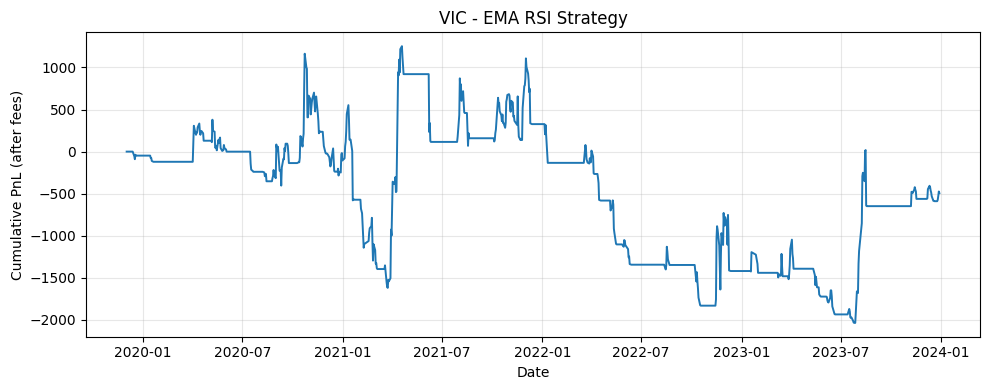

In [16]:
from quantvn.vn.metrics import Backtest_Stock

bt_df = df_signal.copy()
# Backtest_Stock nhận position là số lượng cổ phiếu, nên quy đổi trạng thái 0/1 sang 0/100.
bt_df["position"] = bt_df["position"] * 100 

backtest = Backtest_Stock(bt_df, pnl_type="after_fees")
print(backtest.PNL().tail())
print(backtest.daily_PNL().tail())
print(backtest.estimate_minimum_capital())

backtest.plot_PNL(daily=True, title="VIC - EMA RSI Strategy")

In [17]:
from quantvn.vn.data import get_stock_hist
from quantvn.vn.metrics import Backtest_Stock
from strategy import gen_position

# Chạy lại pipeline đầy đủ để lấy số liệu cuối cùng đưa vào report.
df = get_stock_hist("VIC", resolution="1H")
df_signal = gen_position(df)

bt_df = df_signal.copy()
# Dùng cùng quy mô position như cell backtest ở trên để metric nhất quán.
bt_df["position"] = bt_df["position"] * 100

backtest = Backtest_Stock(bt_df, pnl_type="after_fees")

pnl = backtest.PNL()
daily_pnl = backtest.daily_PNL()
trades = bt_df["position"].diff().abs().fillna(0)

total_trades = int((trades > 0).sum())
final_pnl = pnl.iloc[-1]
min_capital = backtest.estimate_minimum_capital()

drawdown = daily_pnl - daily_pnl.cummax()
max_drawdown = drawdown.min()

daily_return = daily_pnl.diff().dropna()
win_rate = (daily_return > 0).mean()

print("Final PnL:", final_pnl)
print("Minimum capital:", min_capital)
print("Total trades:", total_trades)
print("Win rate:", win_rate)
print("Max drawdown:", max_drawdown)
print(df_signal[["Date", "time", "Close", "rsi_14", "signal", "position"]].tail())

Final PnL: -493.6059999999969
Minimum capital: 11553.612999999996
Total trades: 159
Win rate: 0.15014720314033367
Max drawdown: -3289.2480000000014
            Date      time  Close     rsi_14  signal  position
5095  2023-12-29  09:00:00  44.80  75.037249       1         1
5096  2023-12-29  10:00:00  44.75  73.226655       0         1
5097  2023-12-29  11:00:00  44.65  69.609021       0         1
5098  2023-12-29  13:00:00  44.50  64.464423       0         1
5099  2023-12-29  14:00:00  44.60  66.254983       0         1
